In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from src import plot, scaling, metrics, utils

In [3]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

runs = pd.DataFrame(data)

selected_obj = []
for obj in data:
    #if obj["dataset"] != "MuSiQue":
    #    continue
    #if obj["model"] != "gpt-4o":
    #    continue
    selected_obj.append(obj)

In [4]:
runs = pd.DataFrame(selected_obj)
prompts = runs["prompt"]
runs = runs[(prompts == "multistep") | (prompts == "cot")]
runs

,ID,dataset,model,prompt,csv_file
0,vy1n12lt,HotpotQA,DeepSeek-V3,cot,vy1n12lt.csv
1,uo2u5m33,HotpotQA,DeepSeek-V3,multistep,uo2u5m33.csv
5,l1vy1axf,MuSiQue,DeepSeek-V3,multistep,l1vy1axf.csv
8,ck1php1l,2WikiMultihopQA,DeepSeek-V3,multistep,ck1php1l.csv
9,kjphnu2e,MuSiQue,DeepSeek-V3,cot,kjphnu2e.csv
10,ej74u5a3,2WikiMultihopQA,DeepSeek-V3,cot,ej74u5a3.csv
13,230q321e,2WikiMultihopQA,Llama-3.3-70B,multistep,230q321e.csv
14,2h1uprtd,HotpotQA,Llama-3.3-70B,multistep,2h1uprtd.csv
15,ukkob161,MuSiQue,Llama-3.3-70B,multistep,ukkob161.csv
18,ry4hwozb,MuSiQue,Llama-3.3-70B,cot,ry4hwozb.csv


In [117]:
import numpy as np
import re

def extract_texts_and_confidences(response: str) -> tuple[list[str], list[float]]:
    """
    Extracts the final answer and confidence/probability from the LLM response.
    Expected format at the end:
    "Final Answer: <answer> Probability: <confidence>"
    """
    response = response.strip().replace("\n", " ")

    # Regex to catch variations in punctuation/spacing
    pattern = r"(?:Final Answer|Answer|Guess|Step \d*)[:\-\s]*(.*?)\s*(?:Probability|Confidence)[:\-\s]*([01](?:\.\d+)?)"

    matches = re.findall(pattern, response, flags=re.MULTILINE)
    texts = [text for text, _ in matches]
    confidences = [float(confidence) for _, confidence in matches]

    return texts, confidences


def extract_features_cot(responses, y_confs):
    """
    responses : list of str   — the CoT text for each samplee
    y_confs   : list/array    — confidence score in [0, 1] for each sample
    returns   : np.ndarray of shape (n_samples, n_features)
    """
    y_confs = np.array(y_confs)
    features = []

    for resp, conf in zip(responses, y_confs):
        words     = resp.split()
        n_chars   = len(resp)
        n_words   = len(words)

        # --- Length features (log-transform to reduce skew) ---
        log_chars  = np.log1p(n_chars)
        log_words  = np.log1p(n_words)

        # --- Reasoning structure ---
        # Counts of newlines as a proxy for reasoning steps/structure
        n_lines    = resp.count('\n') + 1
        log_lines  = np.log1p(n_lines)

        # Avg word length — longer words may indicate more technical reasoning
        avg_word_len = np.mean([len(w) for w in words]) if words else 0.0

        # --- Confidence ---
        # Raw confidence and a logit transform (more linear in log-odds space,
        # which suits logistic regression well)
        logit_conf = np.log(conf + 1e-7) - np.log(1 - conf + 1e-7)

        # --- Interaction: length × uncertainty ---
        # High log_words + low conf = long uncertain reasoning = strong signal
        uncertainty    = 1.0 - conf
        length_x_uncertainty = log_words * uncertainty

        features.append([
            n_words,
            #log_chars,
            #log_words,
            #log_lines,
            #avg_word_len,
            conf,
            #logit_conf,
            #length_x_uncertainty,
        ])

    return np.array(features)

COT_FEATURE_NAMES = [
    'num_words',
    #'log_chars',
    #'log_words',
    #'log_lines',
    #'avg_word_len',
    'conf',
    #'logit_conf',
    #'length_x_uncertainty',
]

In [129]:
import numpy as np
import re


def extract_texts_and_confidences(response: str) -> tuple[list[str], list[float]]:
    response = response.strip().replace("\n", " ")
    pattern = r"(?:Final Answer|Answer|Guess|Step \d*)[:\-\s]*(.*?)\s*(?:Probability|Confidence)[:\-\s]*([01](?:\.\d+)?)"
    matches = re.findall(pattern, response, flags=re.MULTILINE)
    texts = [text for text, _ in matches]
    confidences = [float(confidence) for _, confidence in matches]
    return texts, confidences


def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


def _safe_corr(a, b):
    """Returns 0 if correlation is undefined (zero variance in either array)."""
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    return np.corrcoef(a, b)[0, 1]


def extract_features_multistep(responses) -> np.ndarray:
    features = []
    parsed_responses = responses.apply(extract_texts_and_confidences)

    for texts, confs in parsed_responses:

        # --- Parsing failure: return NaNs, handle externally (see note below) ---
        if len(confs) == 0:
            features.append([np.nan] * len(MULTISTEP_FEATURE_NAMES))
            continue

        confs = np.array(confs, dtype=float)
        confs = np.clip(confs, 1e-7, 1)
        n = len(confs)

        # --- Confidence features ---
        conf_final   = confs[-1]
        conf_mean    = confs.mean()
        conf_min      = confs.min()
        conf_std      = confs.std() if n > 1 else 0.0
        conf_product = np.prod(confs)

        log_product   = np.sum(np.log(np.clip(confs, 1e-7, 1)))
        logit_product = log_product

        # --- Trend features ---
        conf_max_to_final = confs[-1] - confs.max()   # <= 0, spike then drop = negative

        if n > 1:
            slope = float(np.polyfit(range(n), confs, 1)[0])
        else:
            slope = 0.0

        # --- Step count ---
        log_n_steps = np.log1p(n)

        # --- Length features ---
        step_lengths = np.array([np.log1p(len(t.split())) for t in texts])
        mean_step_len    = step_lengths.mean() if len(step_lengths) > 0 else 0.0
        length_conf_corr = _safe_corr(step_lengths, confs) if n > 2 else 0.0

        features.append([
            conf_final,
            conf_mean,
            conf_min,
            #conf_std,
            conf_product,
            n,
            #log_n_steps,
            conf_max_to_final,
            slope,
            mean_step_len,
            #length_conf_corr,
        ])

    return np.array(features)


MULTISTEP_FEATURE_NAMES = [
    'conf_final',
    'conf_mean',
    'conf_min',
    #'conf_std',
    'conf_product',
    'num_steps',
    #'log_n_steps',
    'conf_max_to_final',
    'slope',
    'mean_step_len',
    #'length_conf_corr',
]

### Calculate Metrics

In [19]:
from tqdm import tqdm
from collections import defaultdict  # fix import
from sklearn.model_selection import StratifiedKFold

NUM_SPLITS = 5

def calculate_metrics(runs):
    metrics_list = []
    
    for _, row in tqdm(runs.iterrows(), total=len(runs)):
        csv_file = runs_dir / row["csv_file"]
        run_df = pd.read_csv(csv_file)

        y_true = run_df["gpt_eval"].values
        y_confs = run_df["confidence"].values

        skf = StratifiedKFold(
            n_splits=NUM_SPLITS, shuffle=True, random_state=42
        )

        # central place to store all fold metrics
        fold_metrics = defaultdict(list)

        for train_idx, test_idx in skf.split(y_confs, y_true):
            # Split
            y_train, y_test = y_true[train_idx], y_true[test_idx]
            conf_train, conf_test = y_confs[train_idx], y_confs[test_idx]

            # --- Before scaling ---
            fold_metrics["ece"].append( metrics.expected_calibration_error(y_test, conf_test) )
            fold_metrics["brier"].append( metrics.brier_score_loss(y_test, conf_test) )

            # --- Temperature scaling ---
            adj_confs, T = scaling.temperature_scaling( conf_train, conf_test, y_train, return_T=True )

            fold_metrics["ece_t"].append( metrics.expected_calibration_error(y_test, adj_confs) )
            fold_metrics["brier_t"].append( metrics.brier_score_loss(y_test, adj_confs) )
            fold_metrics["T"].append(T)

            # --- Feature extraction ---
            responses = run_df["response"]

            if row["prompt"] == "cot":
                features = extract_features_cot(responses, y_confs)
            elif row["prompt"] == "multistep":
                features = extract_features_multistep(responses)
            else:
                print("Unknown Prompt", row["prompt"])
                continue

            features_train = features[train_idx]
            features_test = features[test_idx]

            # --- Logistic regression scaling ---
            adjusted_confs, model = scaling.logistic_regression( features_train, features_test, y_train, return_model=True )

            fold_metrics["ece_log"].append( metrics.expected_calibration_error(y_test, adjusted_confs) )
            fold_metrics["brier_log"].append( metrics.brier_score_loss(y_test, adjusted_confs) )
            fold_metrics["log_model"].append(model)

        # --- Aggregate ---
        m = {col: row[col] for col in ["ID", "dataset", "model", "prompt"]}

        # mean + std for all tracked metrics
        for key, values in fold_metrics.items():
            if key in ["log_model", "T"]:  # don't aggregate models numerically
                m[key] = values
            else:
                m[key] = np.mean(values)
                m[f"{key}_se"] = np.std(values)

        # extra global metrics
        m["acc"] = y_true.mean()
        m["auc"] = metrics.roc_auc_score(y_true, y_confs)
        m["num_samples"] = len(y_true)

        metrics_list.append(m)

    return pd.DataFrame(metrics_list)


In [133]:
selected_runs = runs[runs["model"] == "gpt-4o"]
runs_multistep = selected_runs[selected_runs["prompt"] == "multistep"]
metrics_df = calculate_metrics(runs_multistep)
#gpt_4o = runs
#calculate_metrics(gpt_4o)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:05<00:00,  1.83s/it]


In [134]:
model_eval = metrics_df[metrics_df["prompt"] == "multistep"].explode("log_model")
model_eval["features"] = model_eval["log_model"].apply(lambda m: list(zip(MULTISTEP_FEATURE_NAMES, m.coef_[0])))
model_eval = model_eval.explode("features")
model_eval[["feature", "coef"]] = model_eval["features"].to_list()
model_eval = model_eval[["dataset", "feature", "coef"]]

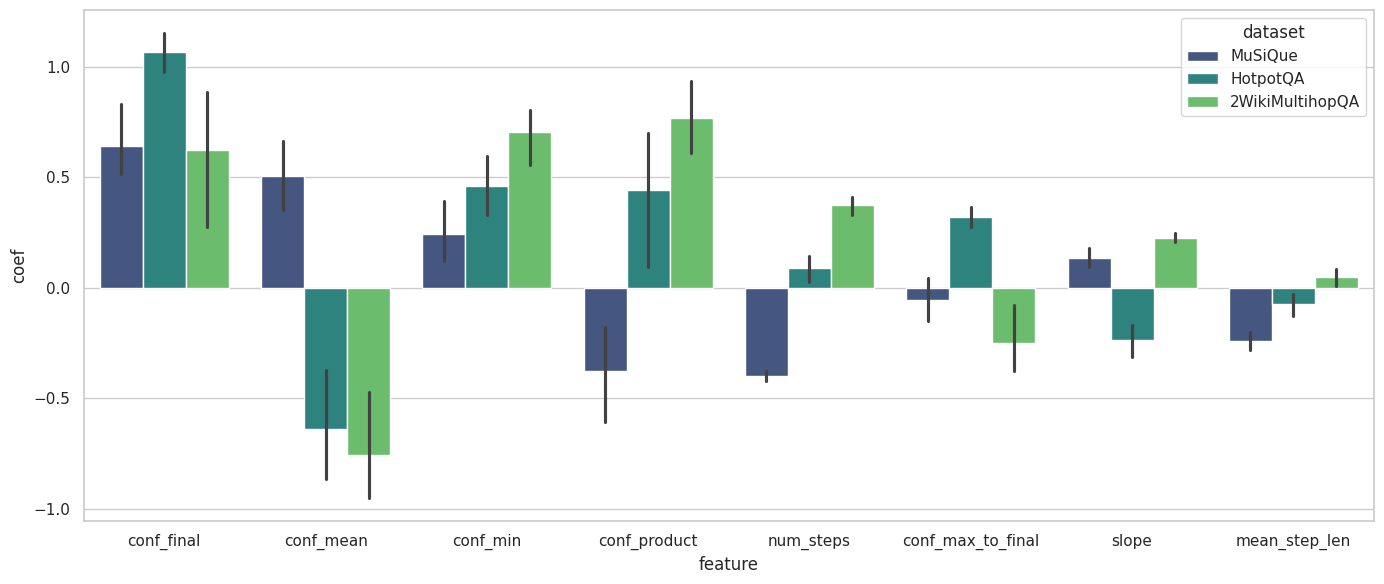

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=model_eval, x="feature", y="coef", hue="dataset", palette="viridis")

plt.tight_layout()
plt.show()

In [118]:
#gpt_4o = runs[runs["model"] == "gpt-4o"]
runs_cot = runs[runs["prompt"] == "cot"]
metrics_df = calculate_metrics(runs_cot)
#gpt_4o = runs
#calculate_metrics(gpt_4o)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:08<00:00,  1.41it/s]


In [119]:
model_eval = metrics_df[metrics_df["prompt"] == "cot"].explode("log_model")
model_eval["features"] = model_eval["log_model"].apply(lambda m: list(zip(COT_FEATURE_NAMES, m.coef_[0])))
model_eval = model_eval.explode("features")
model_eval[["feature", "coef"]] = model_eval["features"].to_list()
model_eval = model_eval[["dataset", "feature", "coef"]]

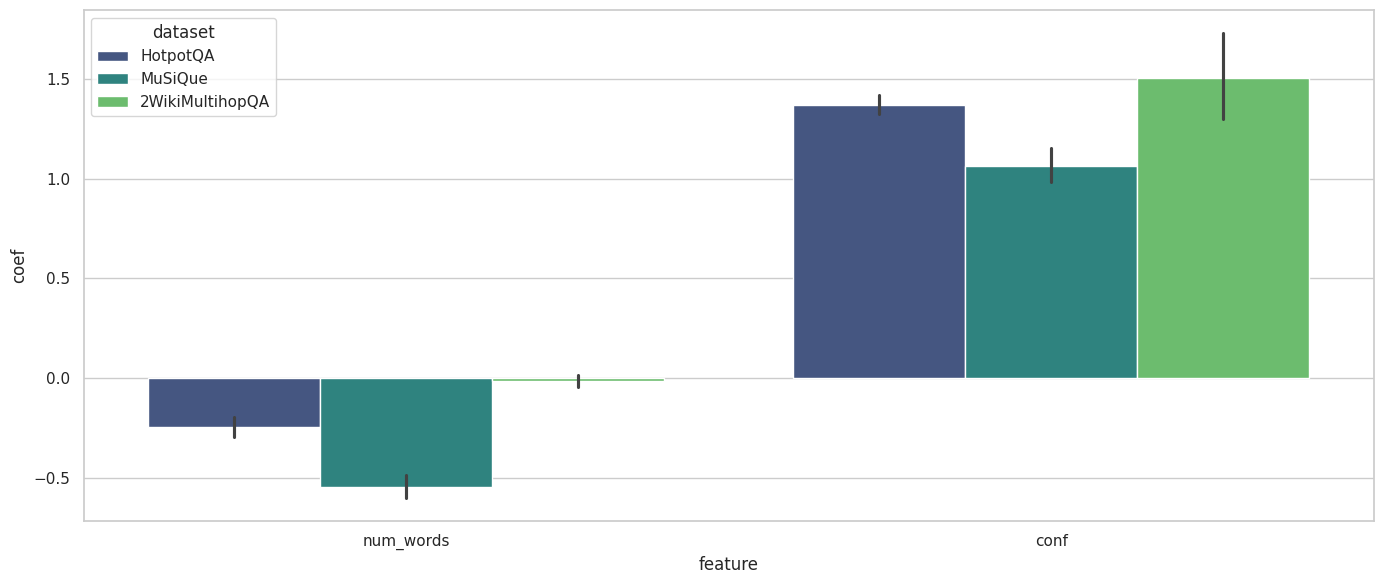

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=model_eval, x="feature", y="coef", hue="dataset", palette="viridis")

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric_list = [["ece", "ece-t"], ["brier", "brier-t"], ["auc", "acc"]]
num_groups = len(metric_list)

def plot_metrics(df, hue="dataset", x="prompt", hue_order=None, x_order=None):
    if hue == "dataset" and hue_order is None:
        hue_order = ['HotpotQA', '2WikiMultihopQA', 'MuSiQue']
    elif hue_order is None:
        hue_order = sorted(df[hue].unique())

    if x == "prompt" and x_order is None:
        x_order =['multistep', 'cot', 'top-k', 'direct'] 
    elif x_order is None:
        x_order = sorted(df[x].unique())
    # 2. Styling and Configuration
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(num_groups, 2, figsize=(15, 6*num_groups),sharey=True)
    
    # Helper function to overlay pre-calculated SE error bars
    def add_error_bars(ax, data, x_col, y_col, hue_col, err_col, x_order, hue_order):
        n_hues = len(hue_order)
        width = 0.8 / n_hues 
        for i, hue in enumerate(hue_order):
            subset = data[data[hue_col] == hue].set_index(x_col).reindex(x_order)
            # Calculate precise X coordinates for the bars within the groups
            x_pos = np.arange(len(x_order)) + (i - (n_hues - 1) / 2) * width
            ax.errorbar(x_pos, subset[y_col], yerr=subset[err_col], 
                        fmt='none', c='black', capsize=4, elinewidth=1)
            
    for i, m_pair in enumerate(metric_list):
        # 3. Plot ECE
        for j, m in enumerate(m_pair):
            ax = axes[i,j]
            sns.barplot(data=df, x=x, y=m, hue=hue, 
                        order=x_order, hue_order=hue_order, ax=ax, palette="viridis")
            if f'{m}_se' in df:
                add_error_bars(ax, df, x, m, hue, f'{m}_se', x_order, hue_order)
            ax.set_title(m, fontsize=14)
            ax.set_ylabel(m)
            ax.set_xlabel('Prompt Technique')
    
    plt.tight_layout()
    plt.show()

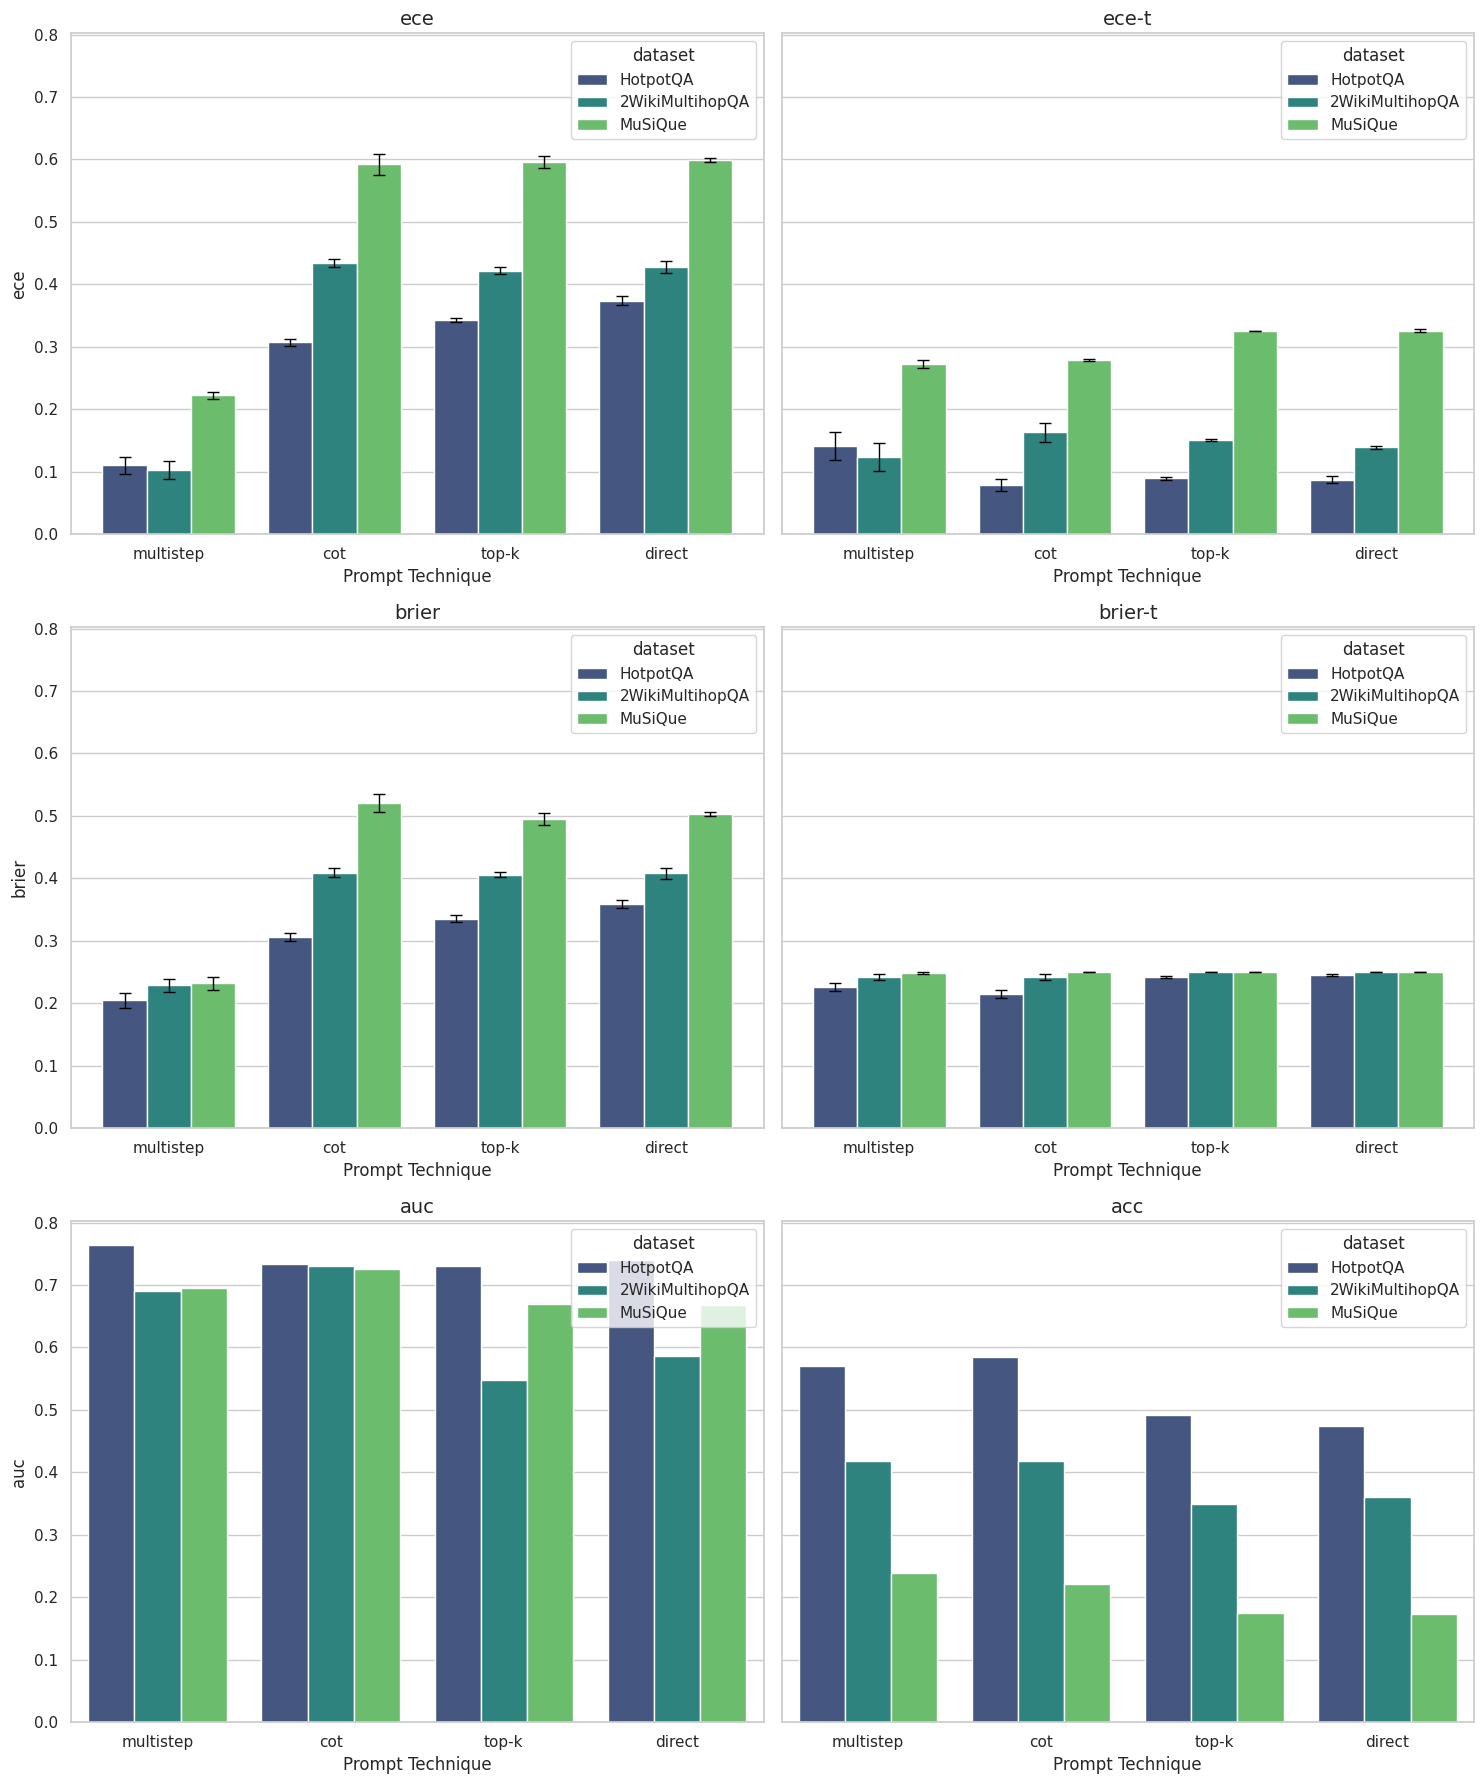

In [9]:
plot_metrics(gpt_4o)

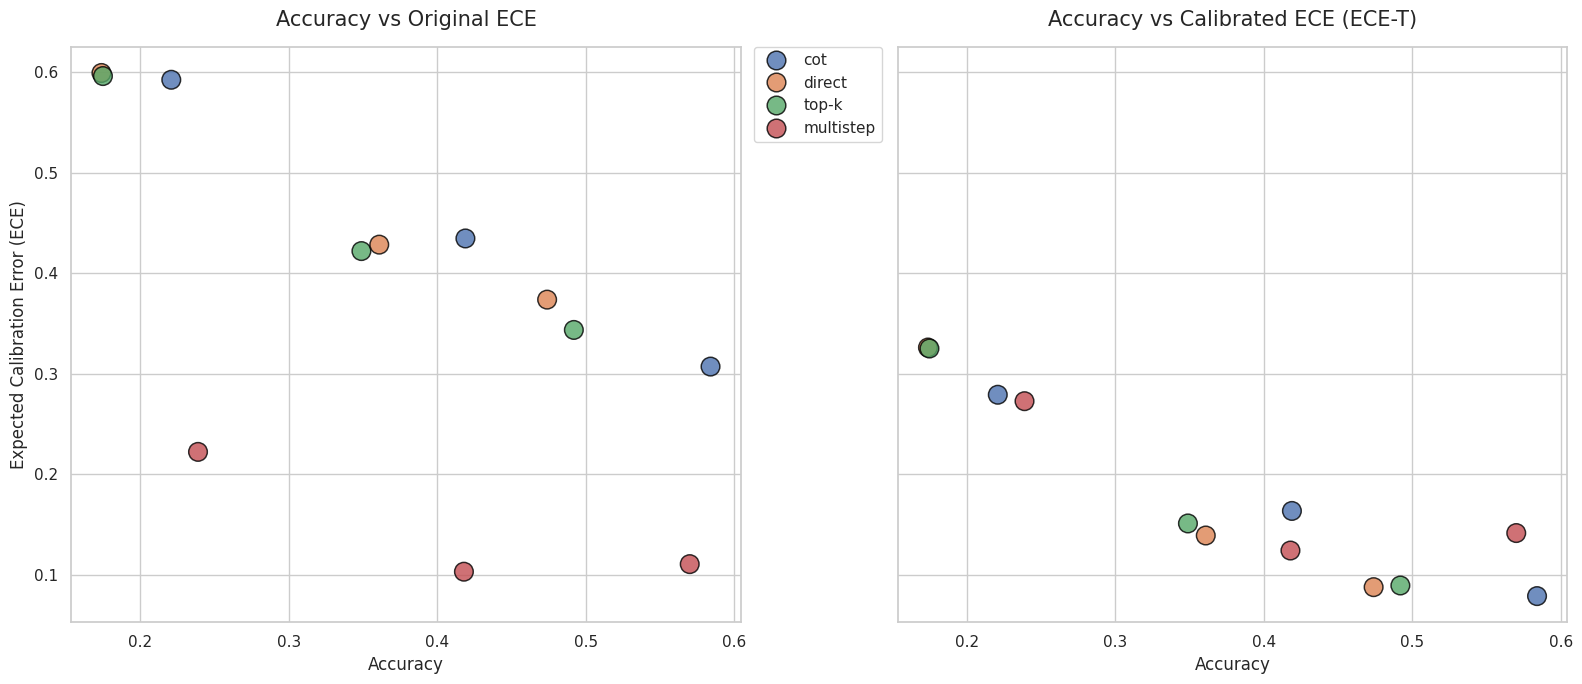

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration_scatter(df):
    """
    Plots Accuracy vs ECE for both original and calibrated values.
    Ideal models appear in the bottom-right (High Accuracy, Low ECE).
    """
    # Setting the theme
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
    
    # Common aesthetic parameters
    scatter_kwargs = {
        'hue': 'prompt',
        's': 180,           # Marker size
        'alpha': 0.8,       # Transparency
        'edgecolor': 'black'
    }
    
    # Panel 1: Original ECE
    sns.scatterplot(data=df, x='acc', y='ece', ax=axes[0], **scatter_kwargs)
    axes[0].set_title('Accuracy vs Original ECE', fontsize=15, pad=15)
    axes[0].set_ylabel('Expected Calibration Error (ECE)', fontsize=12)
    axes[0].set_xlabel('Accuracy', fontsize=12)
    
    # Panel 2: Calibrated ECE (ece-t)
    # Ensure your dataframe has an 'ece_t' or 'ece-t' column
    sns.scatterplot(data=df, x='acc', y='ece-t', ax=axes[1], **scatter_kwargs)
    axes[1].set_title('Accuracy vs Calibrated ECE (ECE-T)', fontsize=15, pad=15)
    axes[1].set_xlabel('Accuracy', fontsize=12)
    
    # Place legend outside for clarity
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    axes[1].get_legend().remove() # Redundant
    
    plt.tight_layout()
    plt.show()

# To use it:
plot_calibration_scatter(gpt_4o)

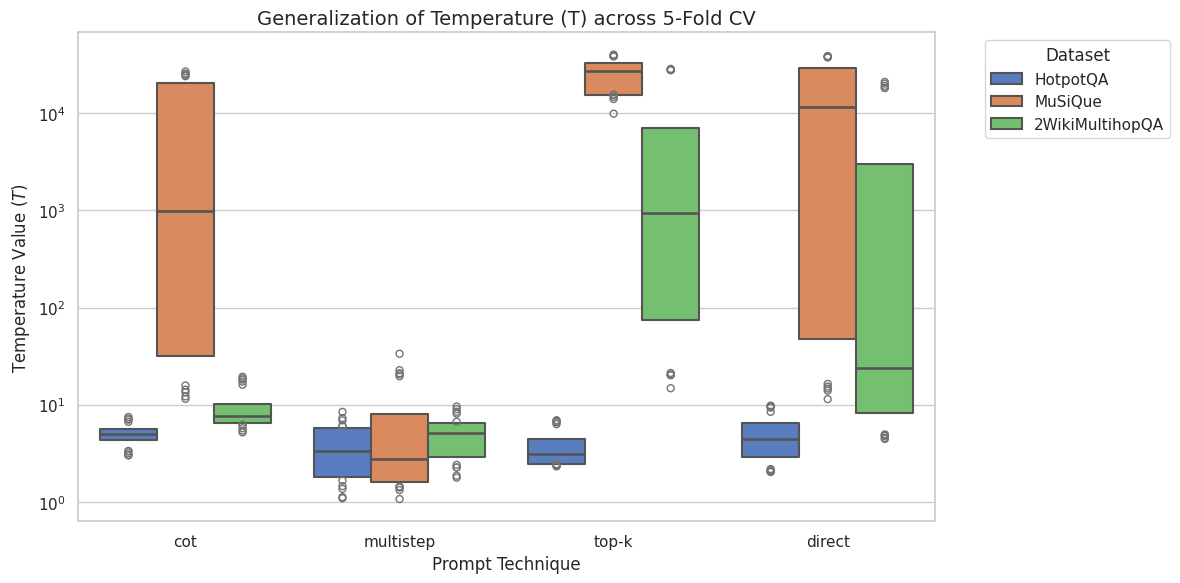

In [41]:
def plot_t_distribution(df, x="prompt", hue="dataset"):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Violin plot shows the full distribution of T across the 10 folds
    sns.boxenplot(
        data=df, 
        x=x, 
        y="T", 
        hue=hue, 
        linewidth=1.5,
        palette="muted",
        log_scale=True,
    )
    
    plt.title(f"Generalization of Temperature (T) across {NUM_SPLITS}-Fold CV", fontsize=14)
    plt.ylabel("Temperature Value ($T$)", fontsize=12)
    plt.xlabel("Prompt Technique", fontsize=12)
    plt.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


df_plot = runs.explode("T")
plot_t_distribution(df_plot)

## Ablation

In [37]:

from tqdm import tqdm
from sklearn.metrics import auc

NUM_SPLITS = 5

thisrow = None

def calculate_metrics_ablation(runs):
    metrics_list = []
    for i, row in tqdm(runs.iterrows(), total=len(runs)):
        csv_file = runs_dir / row["csv_file"]
        run_df = pd.read_csv(csv_file)
        y_true = run_df["gpt_eval"]
        for ab in range(10):
            new_row = row.to_dict()
            y_confs = run_df["confidence"]**ab
    
            skf = StratifiedKFold(n_splits=NUM_SPLITS, shuffle=True, random_state=42,)
    
            ece_values = []
            ece_t_values = []
            bs_t_values = []
            bs_values = []
            auc_values = []
            t_params = []
    
            for fold_idx, (train_idx, test_idx) in enumerate(skf.split(y_confs, y_true)):
                # 1. Split the data
                y_train, y_test = y_true[train_idx],y_true[test_idx], 
                conf_train, conf_test = y_confs[train_idx], y_confs[test_idx], 
    
                #print(len(y_train), len(y_test))
            
                # 2. Calculate Metrics before
                ece = metrics.expected_calibration_error(y_test, conf_test)
                bs = metrics.brier_score_loss(y_test, conf_test)
                
                ece_values.append(ece)
                bs_values.append(bs)
    
                # Adjusting confs
                adj_confs, T = scaling.temperature_scaling(conf_train, conf_test, y_train, return_T = True)
                
                # 4. Calculate ECE After Scaling
                ece_t = metrics.expected_calibration_error(y_test, adj_confs)
                bs_t = metrics.brier_score_loss(y_test, adj_confs)
                
                ece_t_values.append(ece_t)
                bs_t_values.append(bs_t)
                t_params.append(T)
    
            #ece_values = metrics.bootstrap_ece(y_true, y_confs, n_bootstrap=100)
            new_row.update({
                "ablation" : ab,
                "ece" :np.mean(ece_values),
                "ece_se" :np.std(ece_values),
                "brier" :np.mean(bs_values),
                "brier_se" :np.std(bs_values),
                "ece-t" :np.mean(ece_t_values),
                "ece-t_se" :np.std(ece_t_values),
                "brier-t" :np.mean(bs_t_values),
                "brier-t_se" :np.std(bs_t_values),
                "T" :t_params,
                "T_mean" :np.mean(t_params),
                "T_std" :np.std(t_params),
                "acc" :y_true.mean(),
                "auc" :metrics.roc_auc_score(y_true, y_confs),
                "num_samples" :len(y_true),
            })
            metrics_list.append(new_row)
    return pd.DataFrame(metrics_list)

ablation_runs = runs[runs["prompt"] == "cot"]
metrics_df = calculate_metrics_ablation(ablation_runs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:22<00:00,  6.88s/it]


In [38]:
o4_metrics

,ID,dataset,model,prompt,csv_file,T,ece,ece_se,brier,brier_se,ece-t,ece-t_se,brier-t,brier-t_se,T_mean,T_std,acc,auc,num_samples,ablation
60,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
61,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
62,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
63,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
64,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
65,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
66,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
67,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
68,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
69,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9


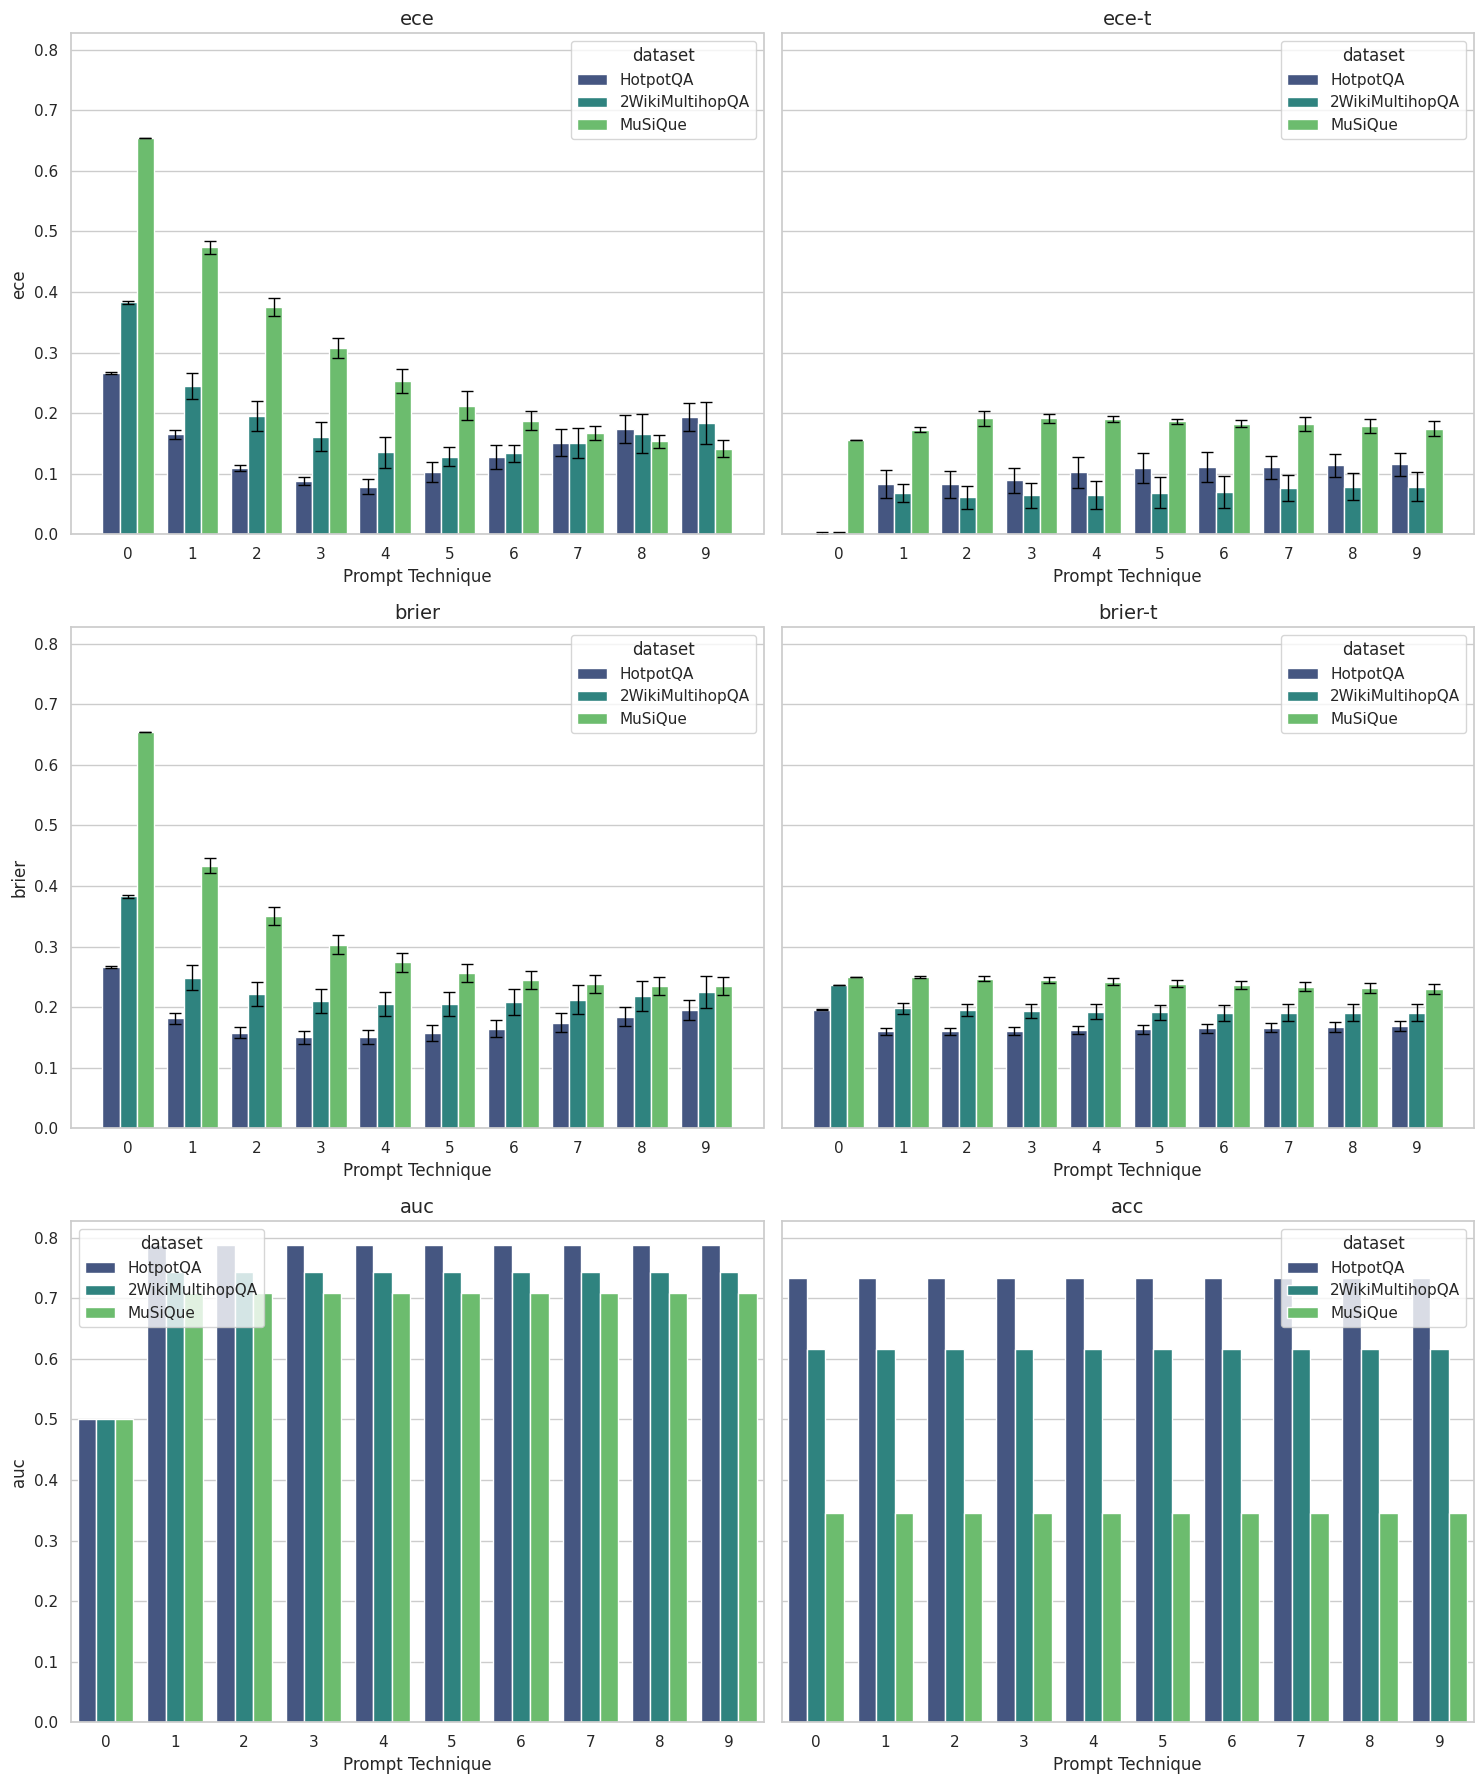

In [39]:
o4_metrics = metrics_df[metrics_df["model"] == "gpt-4o"]
plot_metrics(o4_metrics, x="ablation")

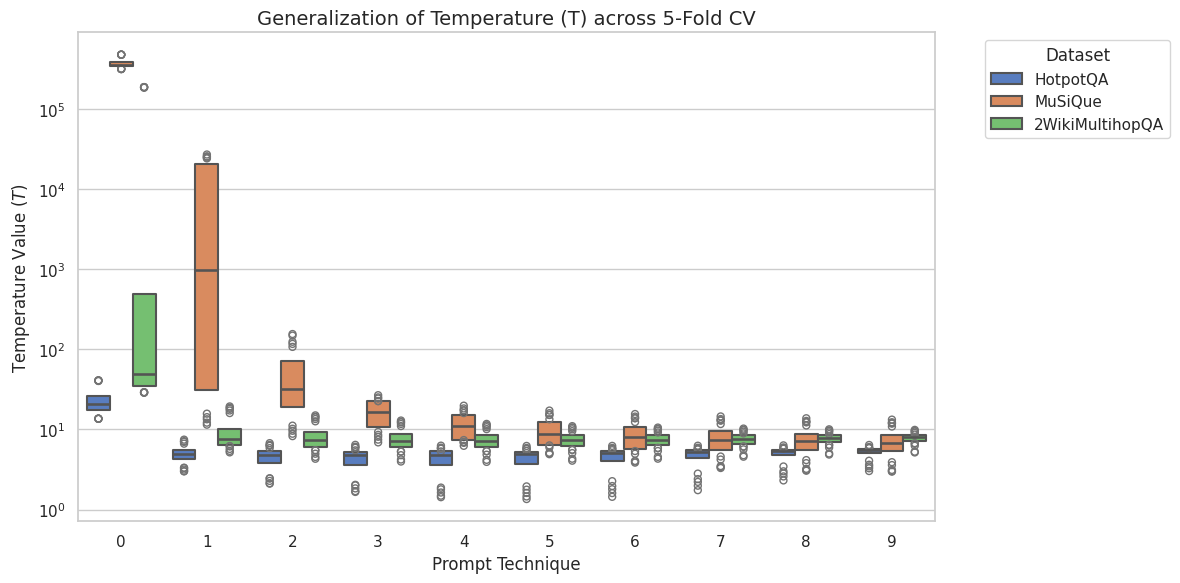

In [42]:
combined_plot_df = metrics_df.explode("T")
plot_t_distribution(combined_plot_df, x="ablation", )